## Importations

In [1]:
# Cellule 1 : Importations
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration esthétique des graphiques
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 12

print("Environnement configuré avec succès.")

Environnement configuré avec succès.


## Chargement des données

In [2]:
# Cellule 2 : Chargement des données
# Utilisation du chemin relatif depuis le dossier 'notebooks/'
data_path = "../data/interim/corpus_combined_raw.csv"

if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print(f"Jeu de données chargé avec succès ! Lignes : {df.shape[0]}, Colonnes : {df.shape[1]}")
else:
    print(f"Erreur : Le fichier est introuvable au chemin {data_path}. Vérifie son emplacement.")

Jeu de données chargé avec succès ! Lignes : 12490, Colonnes : 8


## Inspection structurelle et valeurs manquantes

In [3]:
# Cellule 3 : Diagnostic structurel
print("=== Informations Générales ===")
df.info()

print("\n=== Compte des Valeurs Manquantes ===")
missing_vals = df.isnull().sum()
missing_perc = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Manquants': missing_vals, 'Pourcentage (%)': missing_perc})
display(missing_df)

=== Informations Générales ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12490 entries, 0 to 12489
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   source            12490 non-null  object 
 1   operator          12490 non-null  object 
 2   id                12490 non-null  object 
 3   text              12487 non-null  object 
 4   date              12490 non-null  object 
 5   rating            11695 non-null  float64
 6   engagement_count  12490 non-null  int64  
 7   ref               10408 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 780.8+ KB

=== Compte des Valeurs Manquantes ===


,Manquants,Pourcentage (%)
source,0,0.000000
operator,0,0.000000
id,0,0.000000
text,3,0.024019
date,0,0.000000
rating,795,6.365092
engagement_count,0,0.000000
ref,2082,16.669335


## Analyse de la répartition par Opérateur et par Source

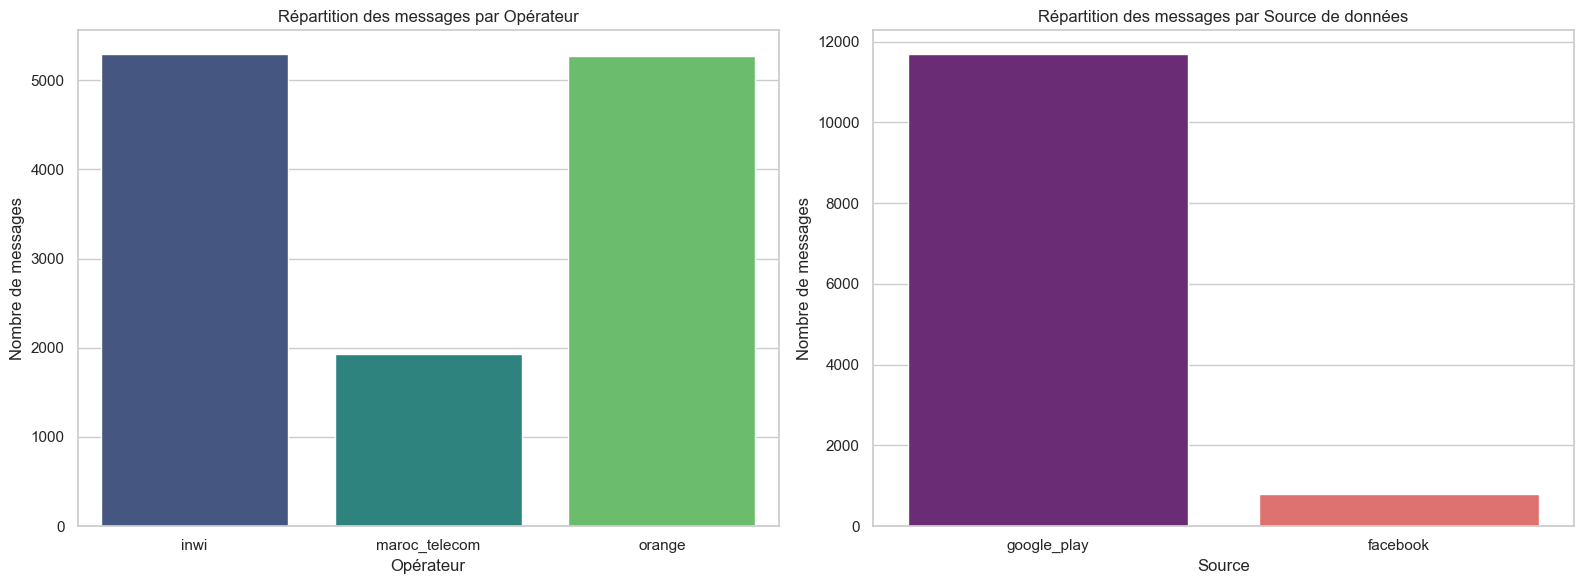

=== Distribution numérique ===
operator
inwi             5294
orange           5269
maroc_telecom    1927
Name: count, dtype: int64

 source
google_play    11695
facebook         795
Name: count, dtype: int64


In [4]:
# Cellule 4 : Distributions des sources et opérateurs
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphique Opérateurs
sns.countplot(data=df, x='operator', hue='operator', legend=False, palette='viridis', ax=axes[0])
axes[0].set_title("Répartition des messages par Opérateur")
axes[0].set_xlabel("Opérateur")
axes[0].set_ylabel("Nombre de messages")

# Graphique Sources
sns.countplot(data=df, x='source', hue='source', legend=False, palette='magma', ax=axes[1])
axes[1].set_title("Répartition des messages par Source de données")
axes[1].set_xlabel("Source")
axes[1].set_ylabel("Nombre de messages")

plt.tight_layout()
plt.show()

print("=== Distribution numérique ===")
print(df['operator'].value_counts())
print("\n", df['source'].value_counts())

## Analyse des Notes (rating) pour Google Play

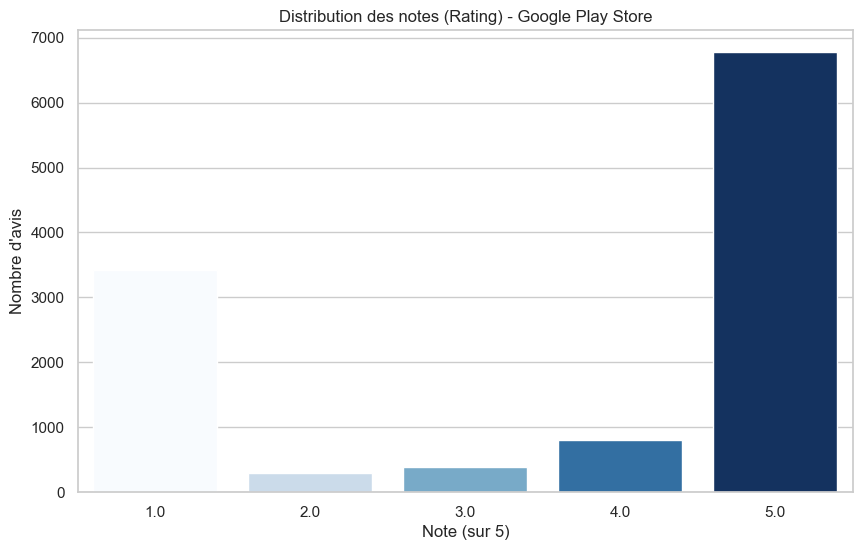

Statistiques descriptives des notes :
count    11695.000000
mean         3.616246
std          1.790071
min          1.000000
25%          1.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: rating, dtype: float64


In [5]:
# Cellule 5 : Analyse des notes (uniquement Google Play)
df_play = df[df['source'] == 'google_play']

sns.countplot(data=df_play, x='rating', hue='rating', legend=False, palette='Blues')
plt.title("Distribution des notes (Rating) - Google Play Store")
plt.xlabel("Note (sur 5)")
plt.ylabel("Nombre d'avis")
plt.show()

print("Statistiques descriptives des notes :")
print(df_play['rating'].describe())

## Analyse textuelle initiale (Longueur des messages)

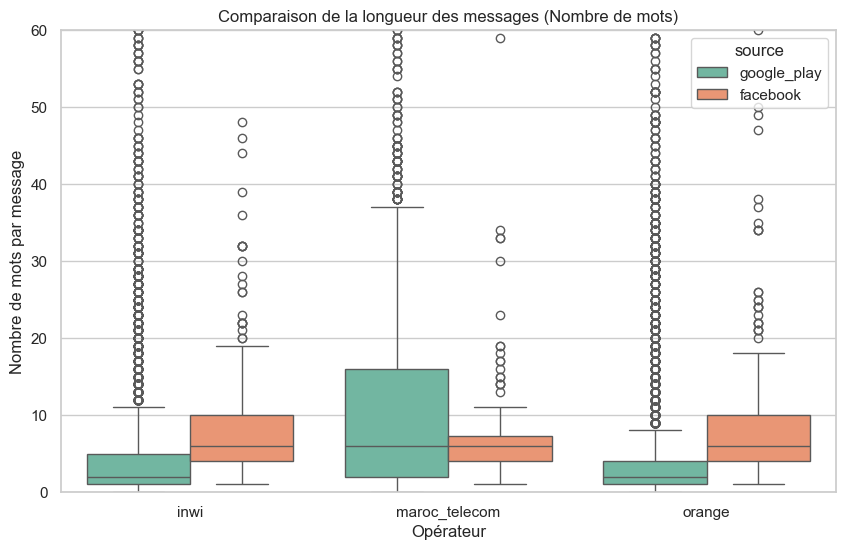

In [6]:
# Cellule 6 : Analyse de la longueur du texte
# On remplit temporairement les textes vides par une chaîne vide pour éviter les erreurs
df['text_length'] = df['text'].fillna('').apply(lambda x: len(str(x).split()))

sns.boxplot(data=df, x='operator', y='text_length', hue='source', palette='Set2')
plt.title("Comparaison de la longueur des messages (Nombre de mots)")
plt.xlabel("Opérateur")
plt.ylabel("Nombre de mots par message")
plt.ylim(0, 60) # On limite l'axe Y pour masquer les outliers extrêmes et mieux voir la distribution
plt.show()

## Échantillonnage pour inspection linguistique

In [7]:
# Cellule 7 : Échantillon de texte pour analyse humaine
print("=== Échantillon aléatoire de commentaires pour inspection visuelle ===")
sample_df = df.dropna(subset=['text']).sample(10, random_state=42)

for idx, row in sample_df.iterrows():
    print(f"[{row['operator'].upper()} | {row['source'].upper()}] : {row['text']}")
    print("-" * 80)

=== Échantillon aléatoire de commentaires pour inspection visuelle ===
[INWI | GOOGLE_PLAY] : super
--------------------------------------------------------------------------------
[ORANGE | GOOGLE_PLAY] : Bravo
--------------------------------------------------------------------------------
[INWI | GOOGLE_PLAY] : C'est simple et efficace merci
--------------------------------------------------------------------------------
[MAROC_TELECOM | GOOGLE_PLAY] : Impossible de créé votre espace Clt même si tu est Clt IAM internet si tu n'a pas de mobile IAM jamais vu sa dans ma vie. J'ai donné une étoile malheursement il ya pas moins d'une étoile.
--------------------------------------------------------------------------------
[INWI | GOOGLE_PLAY] : excellent
--------------------------------------------------------------------------------
[INWI | GOOGLE_PLAY] : application facile efficace.
--------------------------------------------------------------------------------
[INWI | GOOGLE_PLAY] : "

## Moyenne et distribution des notes par opérateur (Google Play)

=== Moyenne des notes par opérateur ===


,operator,Note Moyenne
0,inwi,3.95
1,maroc_telecom,2.00
2,orange,3.83


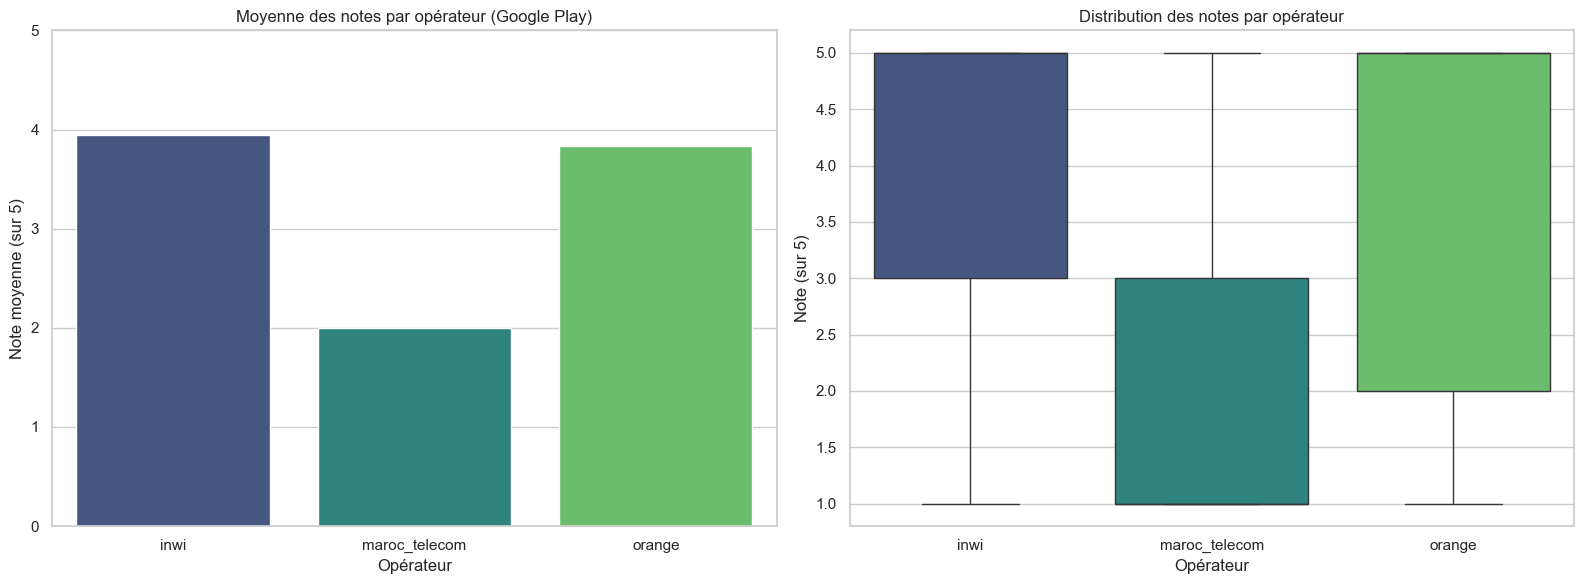

In [8]:
# Cellule 8 : Moyenne et distribution des notes par opérateur (Google Play)

# 1. On isole uniquement les données de Google Play
df_play = df[df['source'] == 'google_play'].copy()

# 2. Calcul des moyennes exactes
moyennes_df = df_play.groupby('operator')['rating'].mean().reset_index()
moyennes_df = moyennes_df.rename(columns={'rating': 'Note Moyenne'})
print("=== Moyenne des notes par opérateur ===")
display(moyennes_df.round(2)) # On arrondit à 2 décimales pour la lisibilité

# 3. Visualisation de la distribution et des moyennes
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphique 1 : Les moyennes (Barplot)
sns.barplot(data=moyennes_df, x='operator', y='Note Moyenne', hue='operator', palette='viridis', ax=axes[0], legend=False)
axes[0].set_title("Moyenne des notes par opérateur (Google Play)")
axes[0].set_xlabel("Opérateur")
axes[0].set_ylabel("Note moyenne (sur 5)")
axes[0].set_ylim(0, 5) # L'axe Y va de 0 à 5

# Graphique 2 : La distribution (Boxplot)
sns.boxplot(data=df_play, x='operator', y='rating', hue='operator', palette='viridis', ax=axes[1], legend=False)
axes[1].set_title("Distribution des notes par opérateur")
axes[1].set_xlabel("Opérateur")
axes[1].set_ylabel("Note (sur 5)")

plt.tight_layout()
plt.show()